# Early-Stage Diabetes Risk Prediction

## 2. Exploratory Data Analysis (EDA)

This notebook explores the diabetes dataset before machine learning model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Load the Dataset

In [2]:
df = pd.read_csv("../data/diabetes_dataset.csv")
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### Dataset Shape

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 31


### Descriptive Statistics

In [4]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


### Target Variable Distribution

`0` = No Diabetes, `1` = Diabetes

In [5]:
target_counts = df["diagnosed_diabetes"].value_counts().sort_index()
target_percentages = df["diagnosed_diabetes"].value_counts(normalize=True).sort_index() * 100
print("Target counts:")
print(target_counts)
print("\nTarget percentages:")
print(target_percentages.round(3))

Target counts:
diagnosed_diabetes
0    40002
1    59998
Name: count, dtype: int64

Target percentages:
diagnosed_diabetes
0    40.002
1    59.998
Name: proportion, dtype: float64


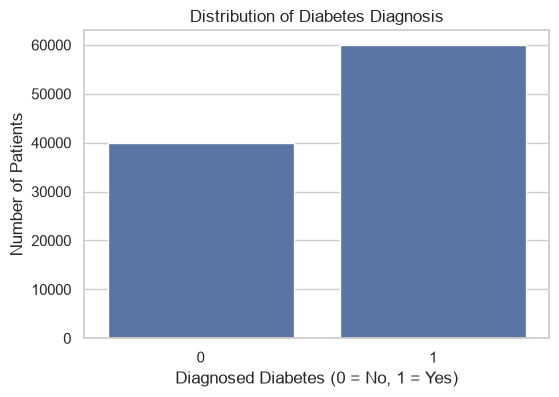

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosed_diabetes")
plt.title("Distribution of Diabetes Diagnosis")
plt.xlabel("Diagnosed Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

**Observation:** The target distribution shows the number and proportion of patients in each diabetes class.

### Numerical Feature Distributions

In [7]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
print("Number of numerical columns:", len(numerical_features))
print(numerical_features)

Number of numerical columns: 24
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diagnosed_diabetes']


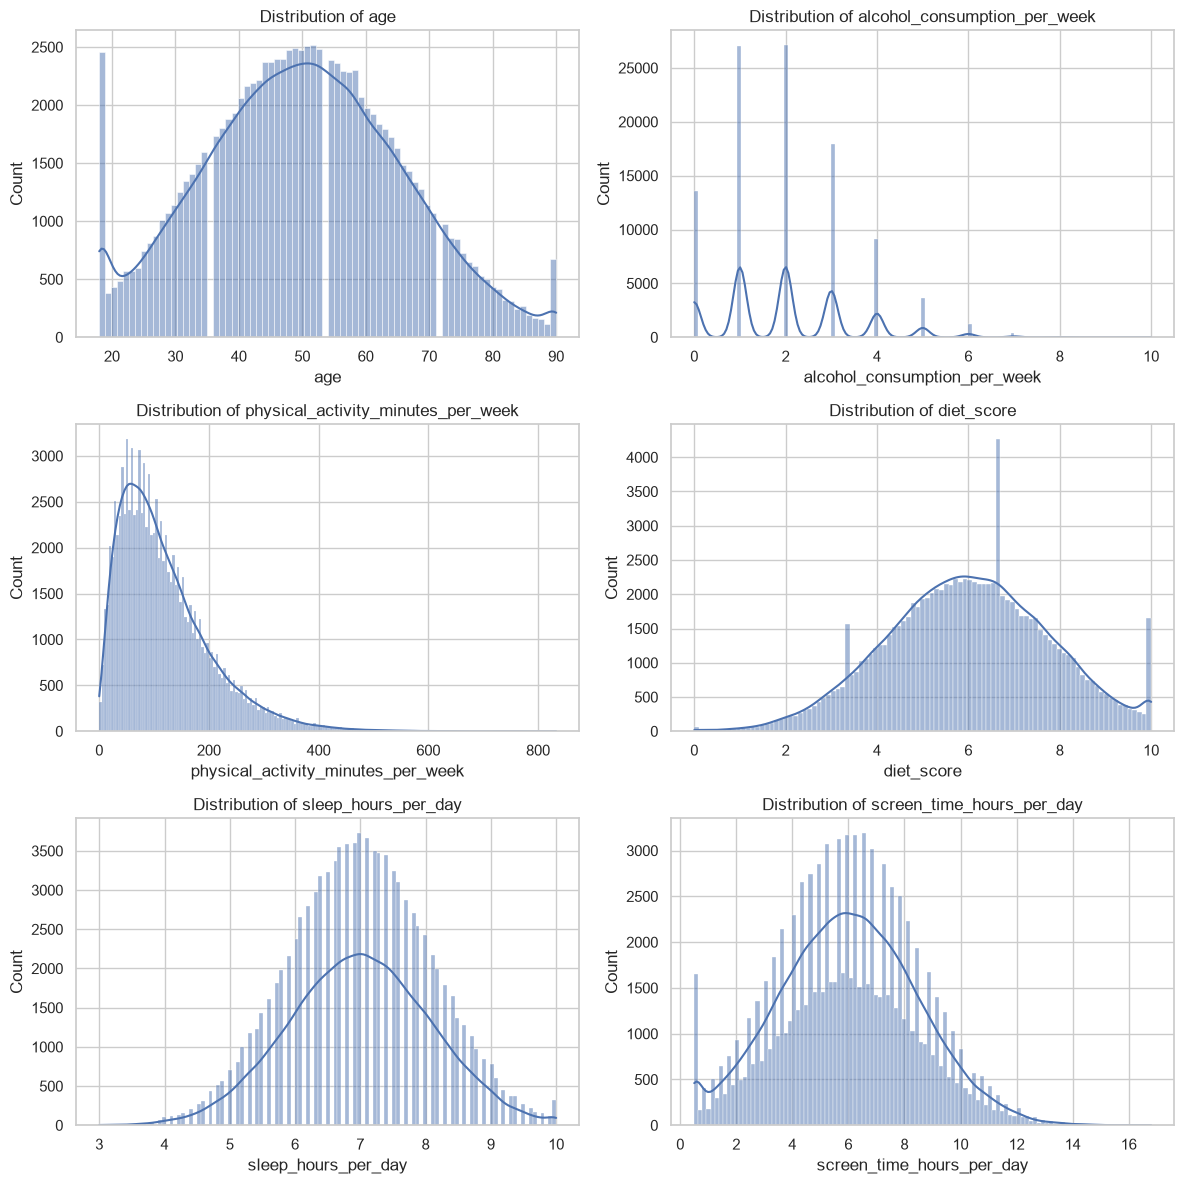

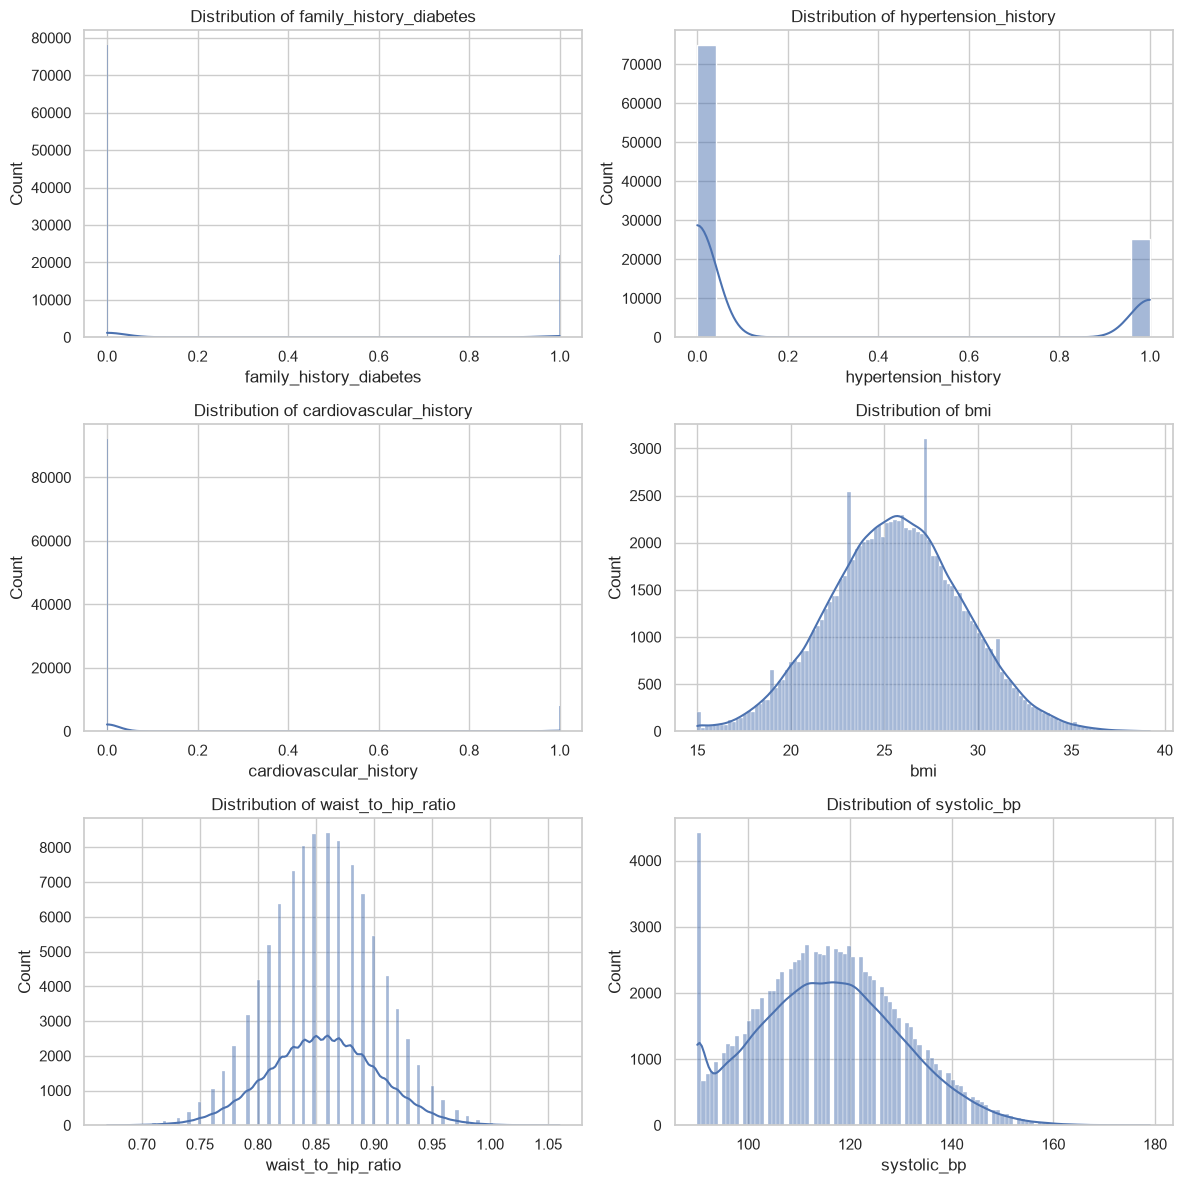

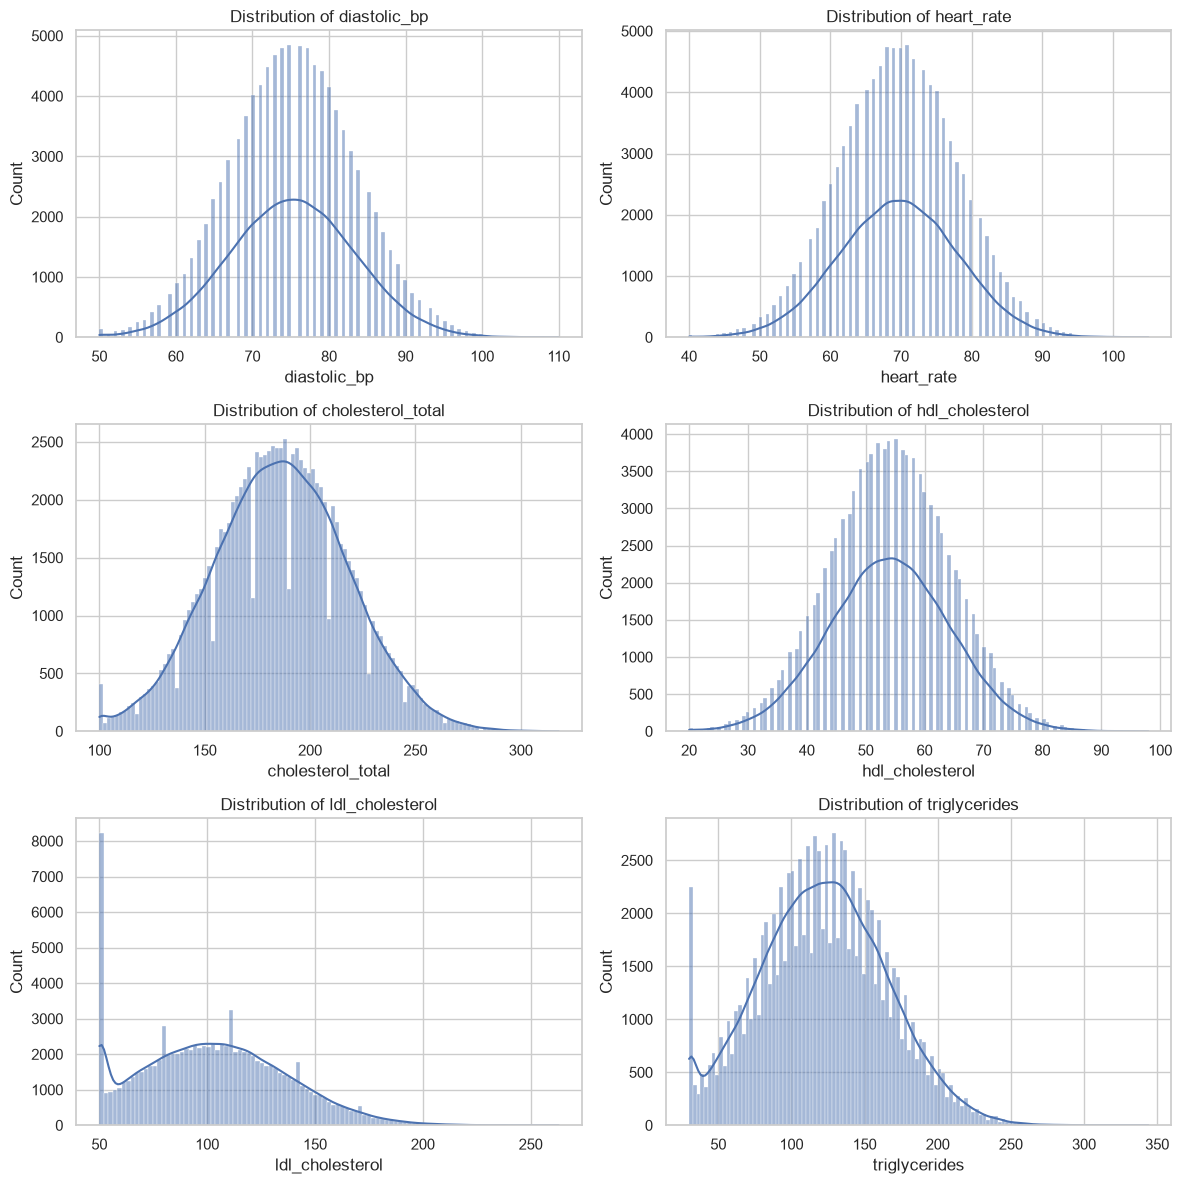

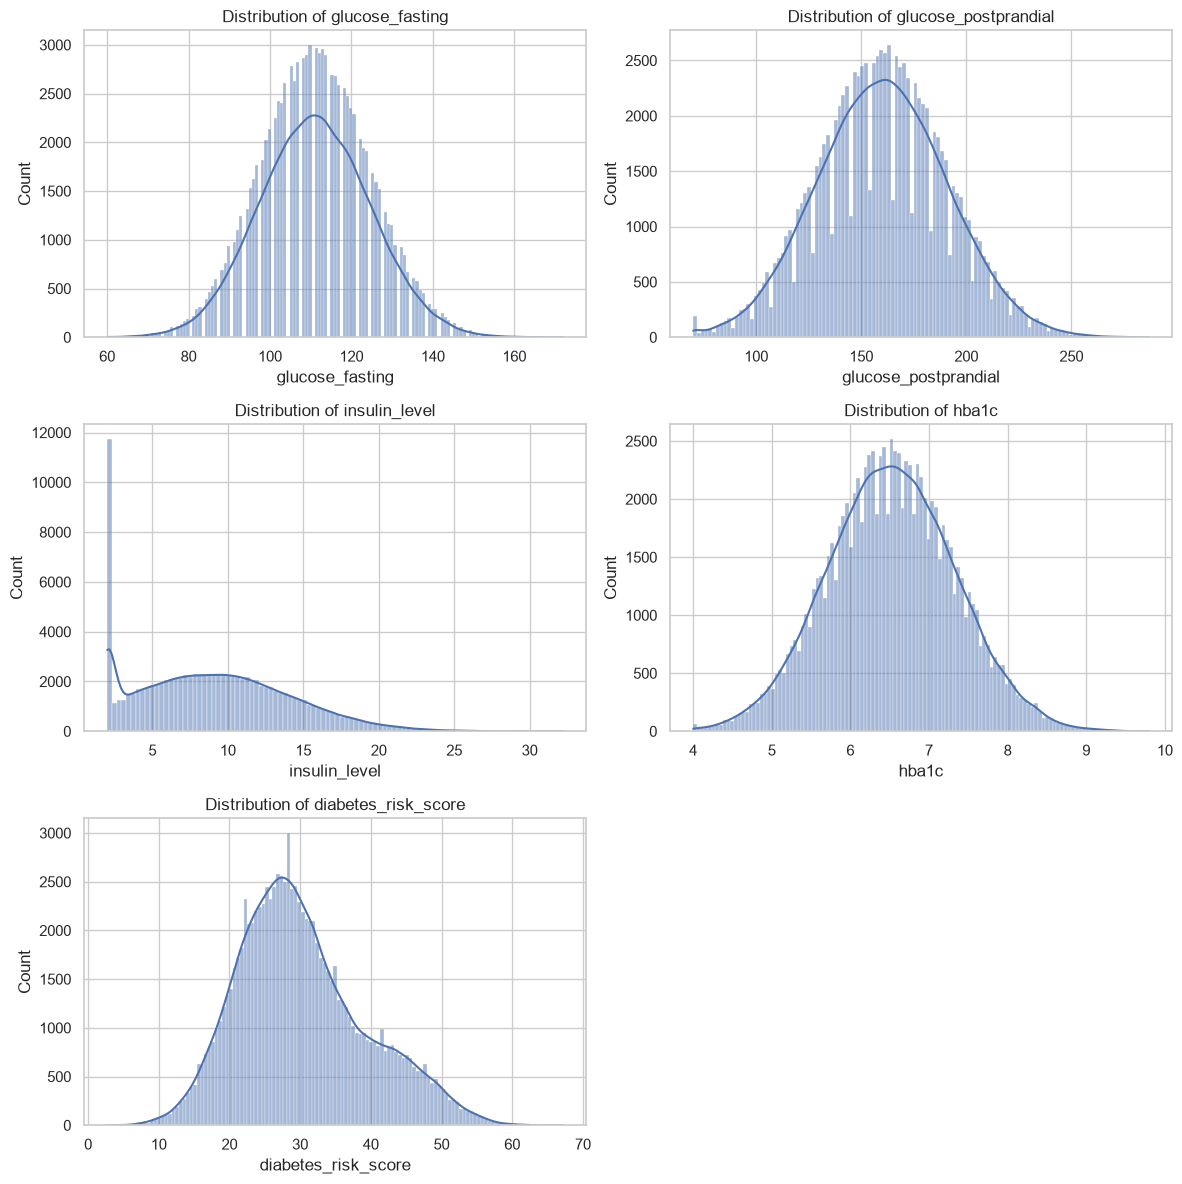

In [8]:
features_to_plot = [col for col in numerical_features if col != "diagnosed_diabetes"]
for start in range(0, len(features_to_plot), 6):
    group = features_to_plot[start:start + 6]
    rows = int(np.ceil(len(group) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, group):
        sns.histplot(data=df, x=feature, kde=True, ax=ax)
        ax.set_title(f"Distribution of {feature}")
    for ax in axes[len(group):]: ax.remove()
    plt.tight_layout(); plt.show()

**Observation:** These plots help identify the central tendency, spread, skewness, and unusual values of numerical features.

### Important Clinical Feature Distributions

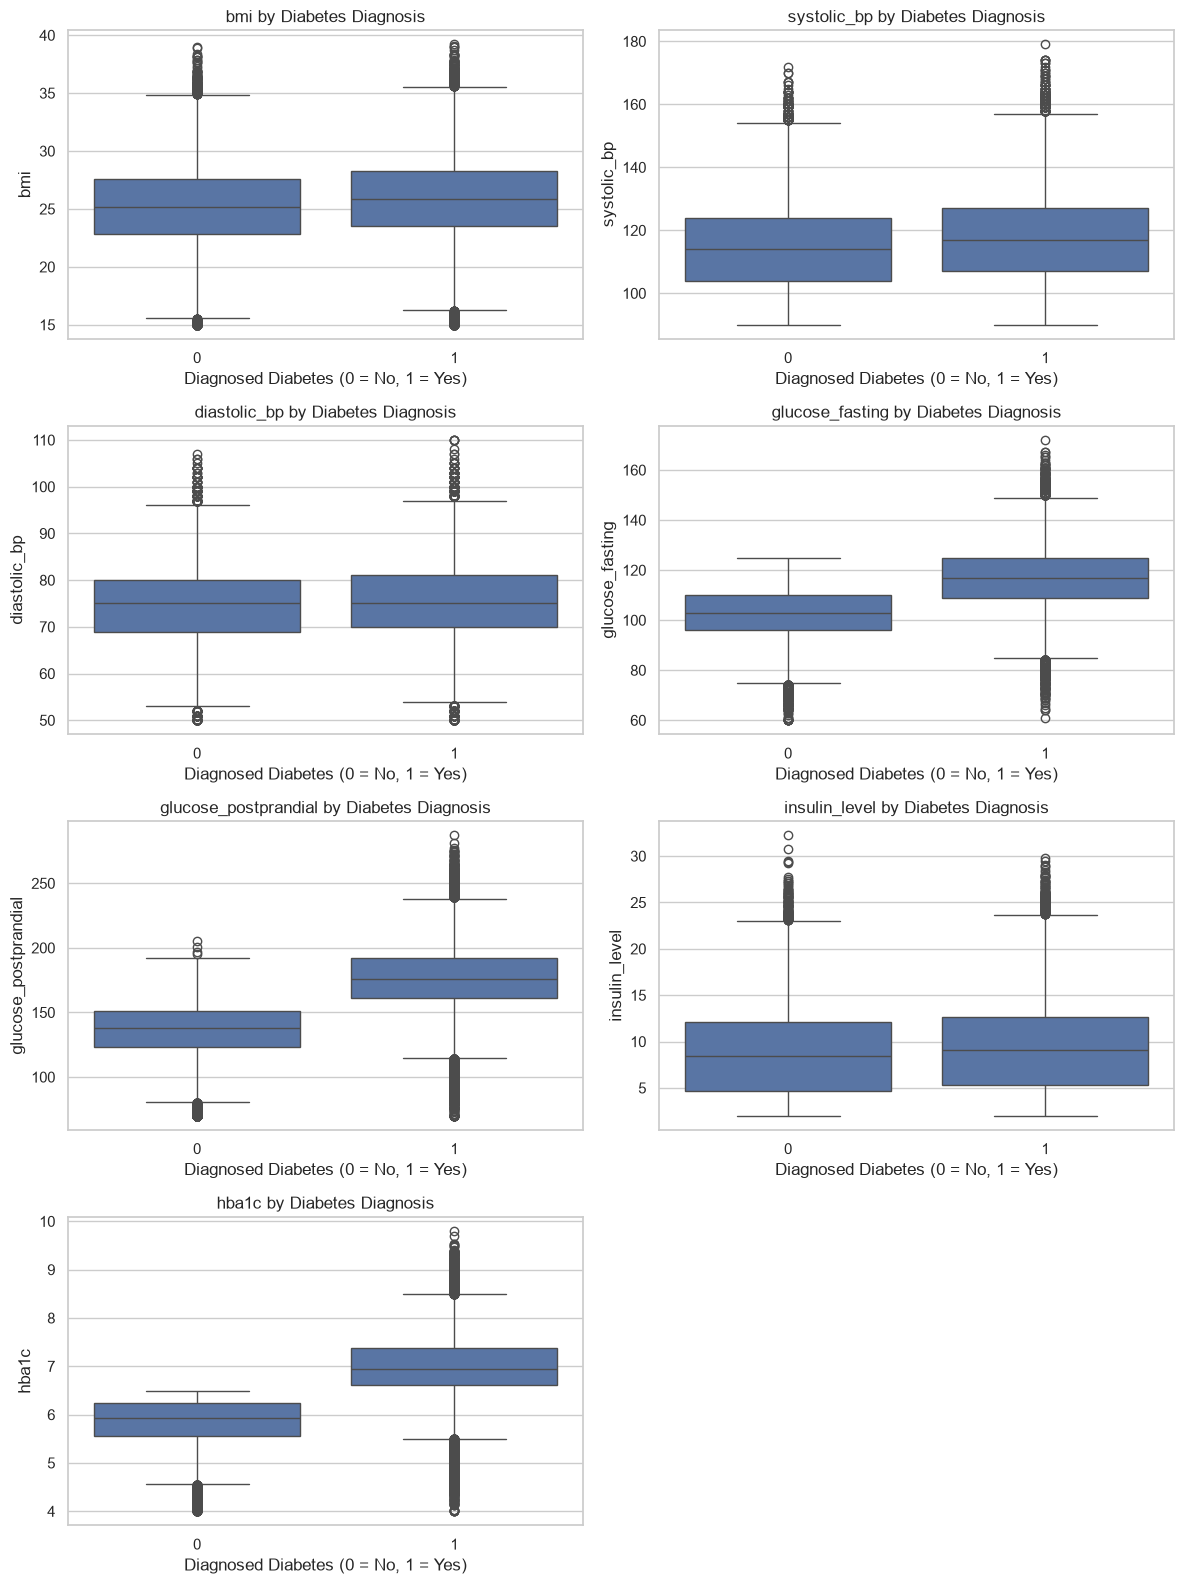

In [9]:
clinical_features = ["bmi", "systolic_bp", "diastolic_bp", "glucose_fasting", "glucose_postprandial", "insulin_level", "hba1c"]
available = [f for f in clinical_features if f in df.columns]
rows = int(np.ceil(len(available) / 2))
fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, available):
    sns.boxplot(data=df, x="diagnosed_diabetes", y=feature, ax=ax)
    ax.set_title(f"{feature} by Diabetes Diagnosis")
    ax.set_xlabel("Diagnosed Diabetes (0 = No, 1 = Yes)")
for ax in axes[len(available):]: ax.remove()
plt.tight_layout(); plt.show()

**Observation:** Box plots compare important clinical variables between diabetes classes and help identify variables that may be useful for prediction.

### Categorical Feature Analysis

In [10]:
categorical_features = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Number of categorical columns:", len(categorical_features))
print(categorical_features)

Number of categorical columns: 7
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']


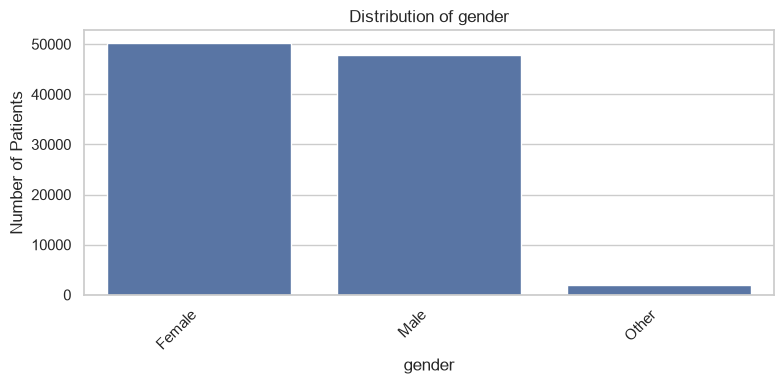

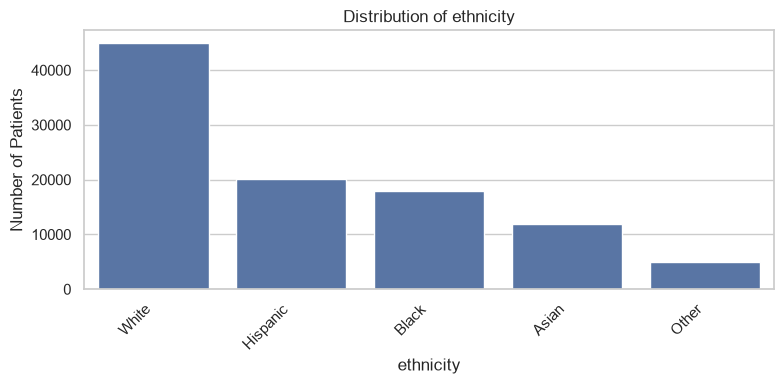

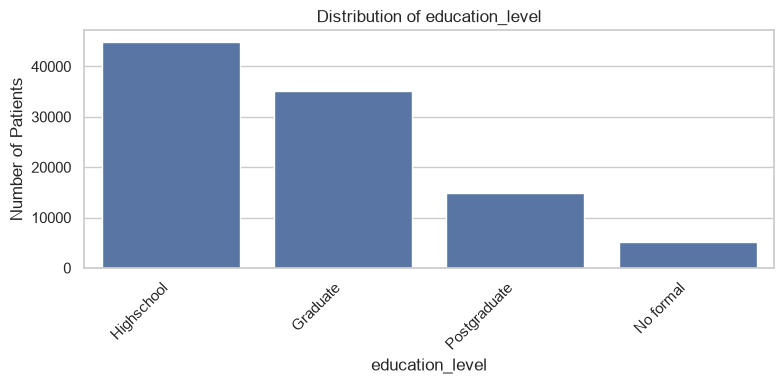

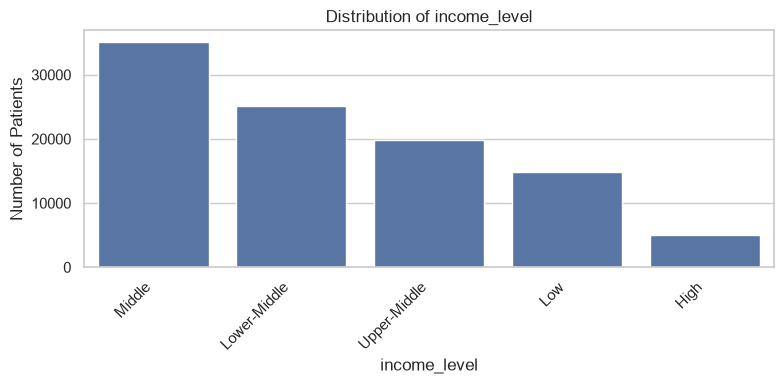

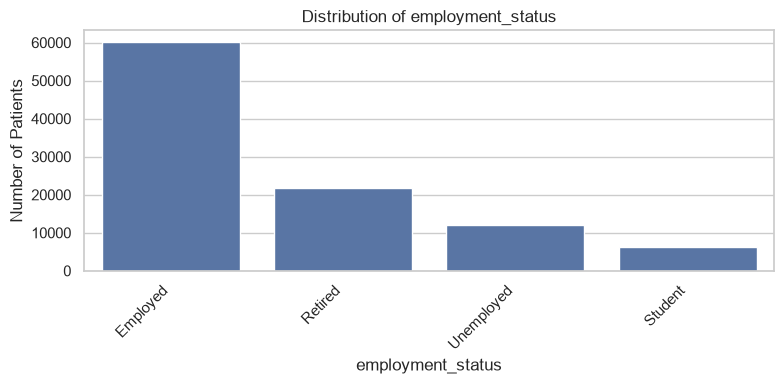

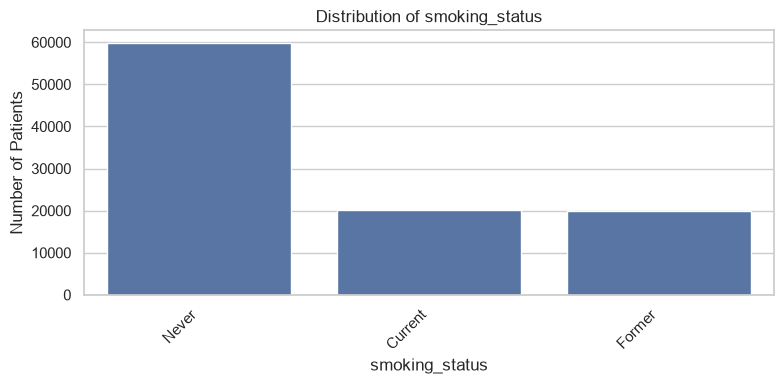

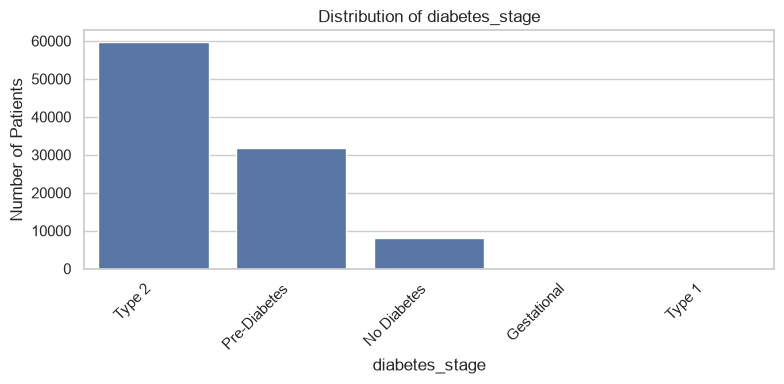

In [11]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    order = df[feature].value_counts().index
    sns.countplot(data=df, x=feature, order=order)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature); plt.ylabel("Number of Patients")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

**Observation:** Categorical plots show the frequency of different patient groups. These variables will require encoding before modelling.

### Correlation Analysis

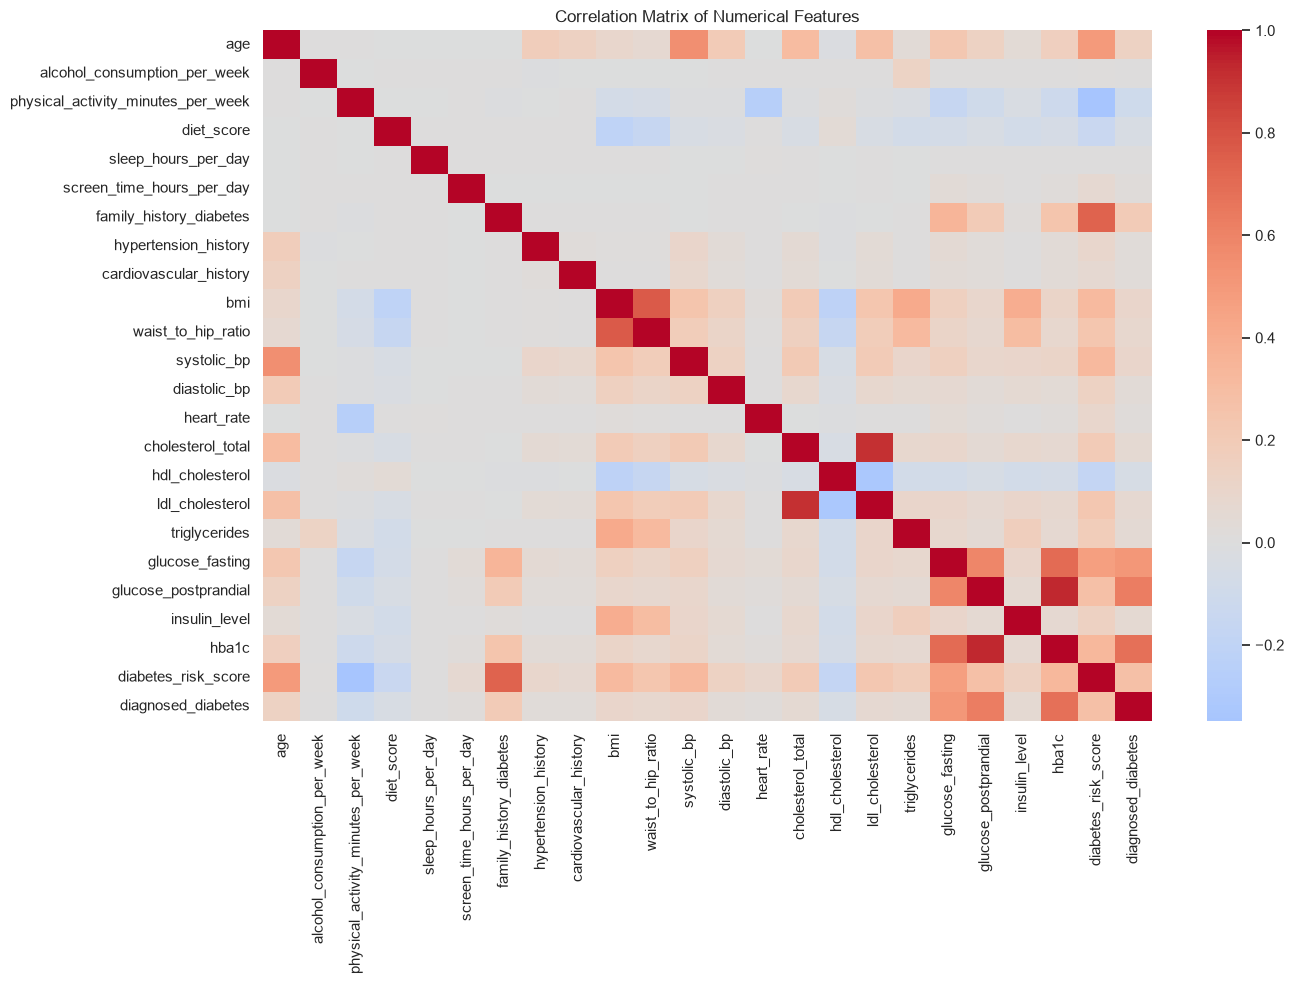

In [12]:
correlation_data = df.select_dtypes(include=np.number)
correlation_matrix = correlation_data.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout(); plt.show()

**Observation:** The correlation matrix helps identify relationships among numerical variables and possible redundancy.

### Numerical Features Most Correlated With the Target

In [13]:
target_correlations = (correlation_matrix["diagnosed_diabetes"].drop("diagnosed_diabetes").sort_values(key=lambda x: x.abs(), ascending=False))
target_correlations

hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
physical_activity_minutes_per_week   -0.100774
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
hdl_cholesterol                      -0.051227
diet_score                           -0.044298
diastolic_bp                          0.035619
cardiovascular_history                0.029793
hypertension_history                  0.027524
heart_rate                            0.022785
screen_time_hours_per_day             0.018127
alcohol_consu

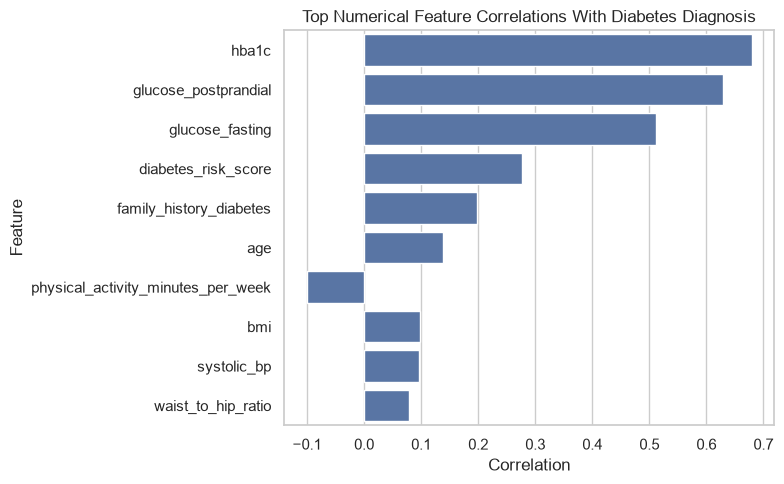

In [14]:
top_n = min(10, len(target_correlations))
plt.figure(figsize=(8, 5))
sns.barplot(x=target_correlations.head(top_n).values, y=target_correlations.head(top_n).index)
plt.title("Top Numerical Feature Correlations With Diabetes Diagnosis")
plt.xlabel("Correlation"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

**Observation:** This ranking is an initial correlation-based view. It is not the final feature-selection method; later we will use XGBoost feature importance.

### EDA Summary

In [15]:
print("EDA Summary")
print("-" * 50)
print(f"Dataset size: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Target classes: {sorted(df['diagnosed_diabetes'].unique())}")
print("\nTarget distribution:")
for cls, count in target_counts.items(): print(f"Class {cls}: {count} records ({target_percentages[cls]:.3f}%)")
print("\nTop numerical correlations with the target:")
print(target_correlations.head(10).round(4))

EDA Summary
--------------------------------------------------
Dataset size: 100000 rows × 31 columns
Numerical features: 24
Categorical features: 7
Target classes: [np.int64(0), np.int64(1)]

Target distribution:
Class 0: 40002 records (40.002%)
Class 1: 59998 records (59.998%)

Top numerical correlations with the target:
hba1c                                 0.6794
glucose_postprandial                  0.6298
glucose_fasting                       0.5109
diabetes_risk_score                   0.2773
family_history_diabetes               0.1979
age                                   0.1377
physical_activity_minutes_per_week   -0.1008
bmi                                   0.0971
systolic_bp                           0.0955
waist_to_hip_ratio                    0.0789
Name: diagnosed_diabetes, dtype: float64


## EDA Conclusions

The exploratory analysis identifies the dataset structure, target distribution, numerical and categorical feature behavior, and relationships among numerical variables. These observations will guide the preprocessing stage.